
# # Exploratory Data Analysis - Real World Healthcare Data

 This notebook explores synthetic healthcare data including:

 - Patient demographics
 - Diagnosis patterns
 - Laboratory results
 - Medication usage
 - Outcomes and survival

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Configure plotting
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [4]:
# Add src to path 
import sys
sys.path.append("../src")

from rwe_health_analytics.data.data_loader import HealthcareDataLoader


INFO:rwe_health_analytics.data.data_loader:Loading all datasets...
INFO:rwe_health_analytics.data.data_loader:Loading demographics from ..\data\raw\demographics.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 10000 patient records
INFO:rwe_health_analytics.data.data_loader:Loading diagnoses from ..\data\raw\diagnoses.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 30035 diagnosis records
INFO:rwe_health_analytics.data.data_loader:Loading lab results from ..\data\raw\lab_results.csv


Loading healthcare datasets...


INFO:rwe_health_analytics.data.data_loader:Loaded 199701 lab results
INFO:rwe_health_analytics.data.data_loader:Loading medications from ..\data\raw\medications.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 21079 medication records
INFO:rwe_health_analytics.data.data_loader:Loading outcomes from ..\data\raw\outcomes.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 23444 outcome events
INFO:rwe_health_analytics.data.data_loader:All datasets loaded successfully!


✓ Data loaded successfully!
DEMOGRAPHICS SUMMARY

Total Patients: 10,000

Age Statistics:
count    10000.000000
mean        54.495500
std         14.887362
min         18.000000
25%         44.000000
50%         54.000000
75%         65.000000
max         95.000000
Name: age, dtype: float64

Gender Distribution:
gender
F    5324
M    4676
Name: count, dtype: int64

Race Distribution:
race
White       6010
Hispanic    1737
Black       1381
Asian        572
Other        300
Name: count, dtype: int64

Smoking Status:
smoking_status
Never      4980
Former     3056
Current    1964
Name: count, dtype: int64


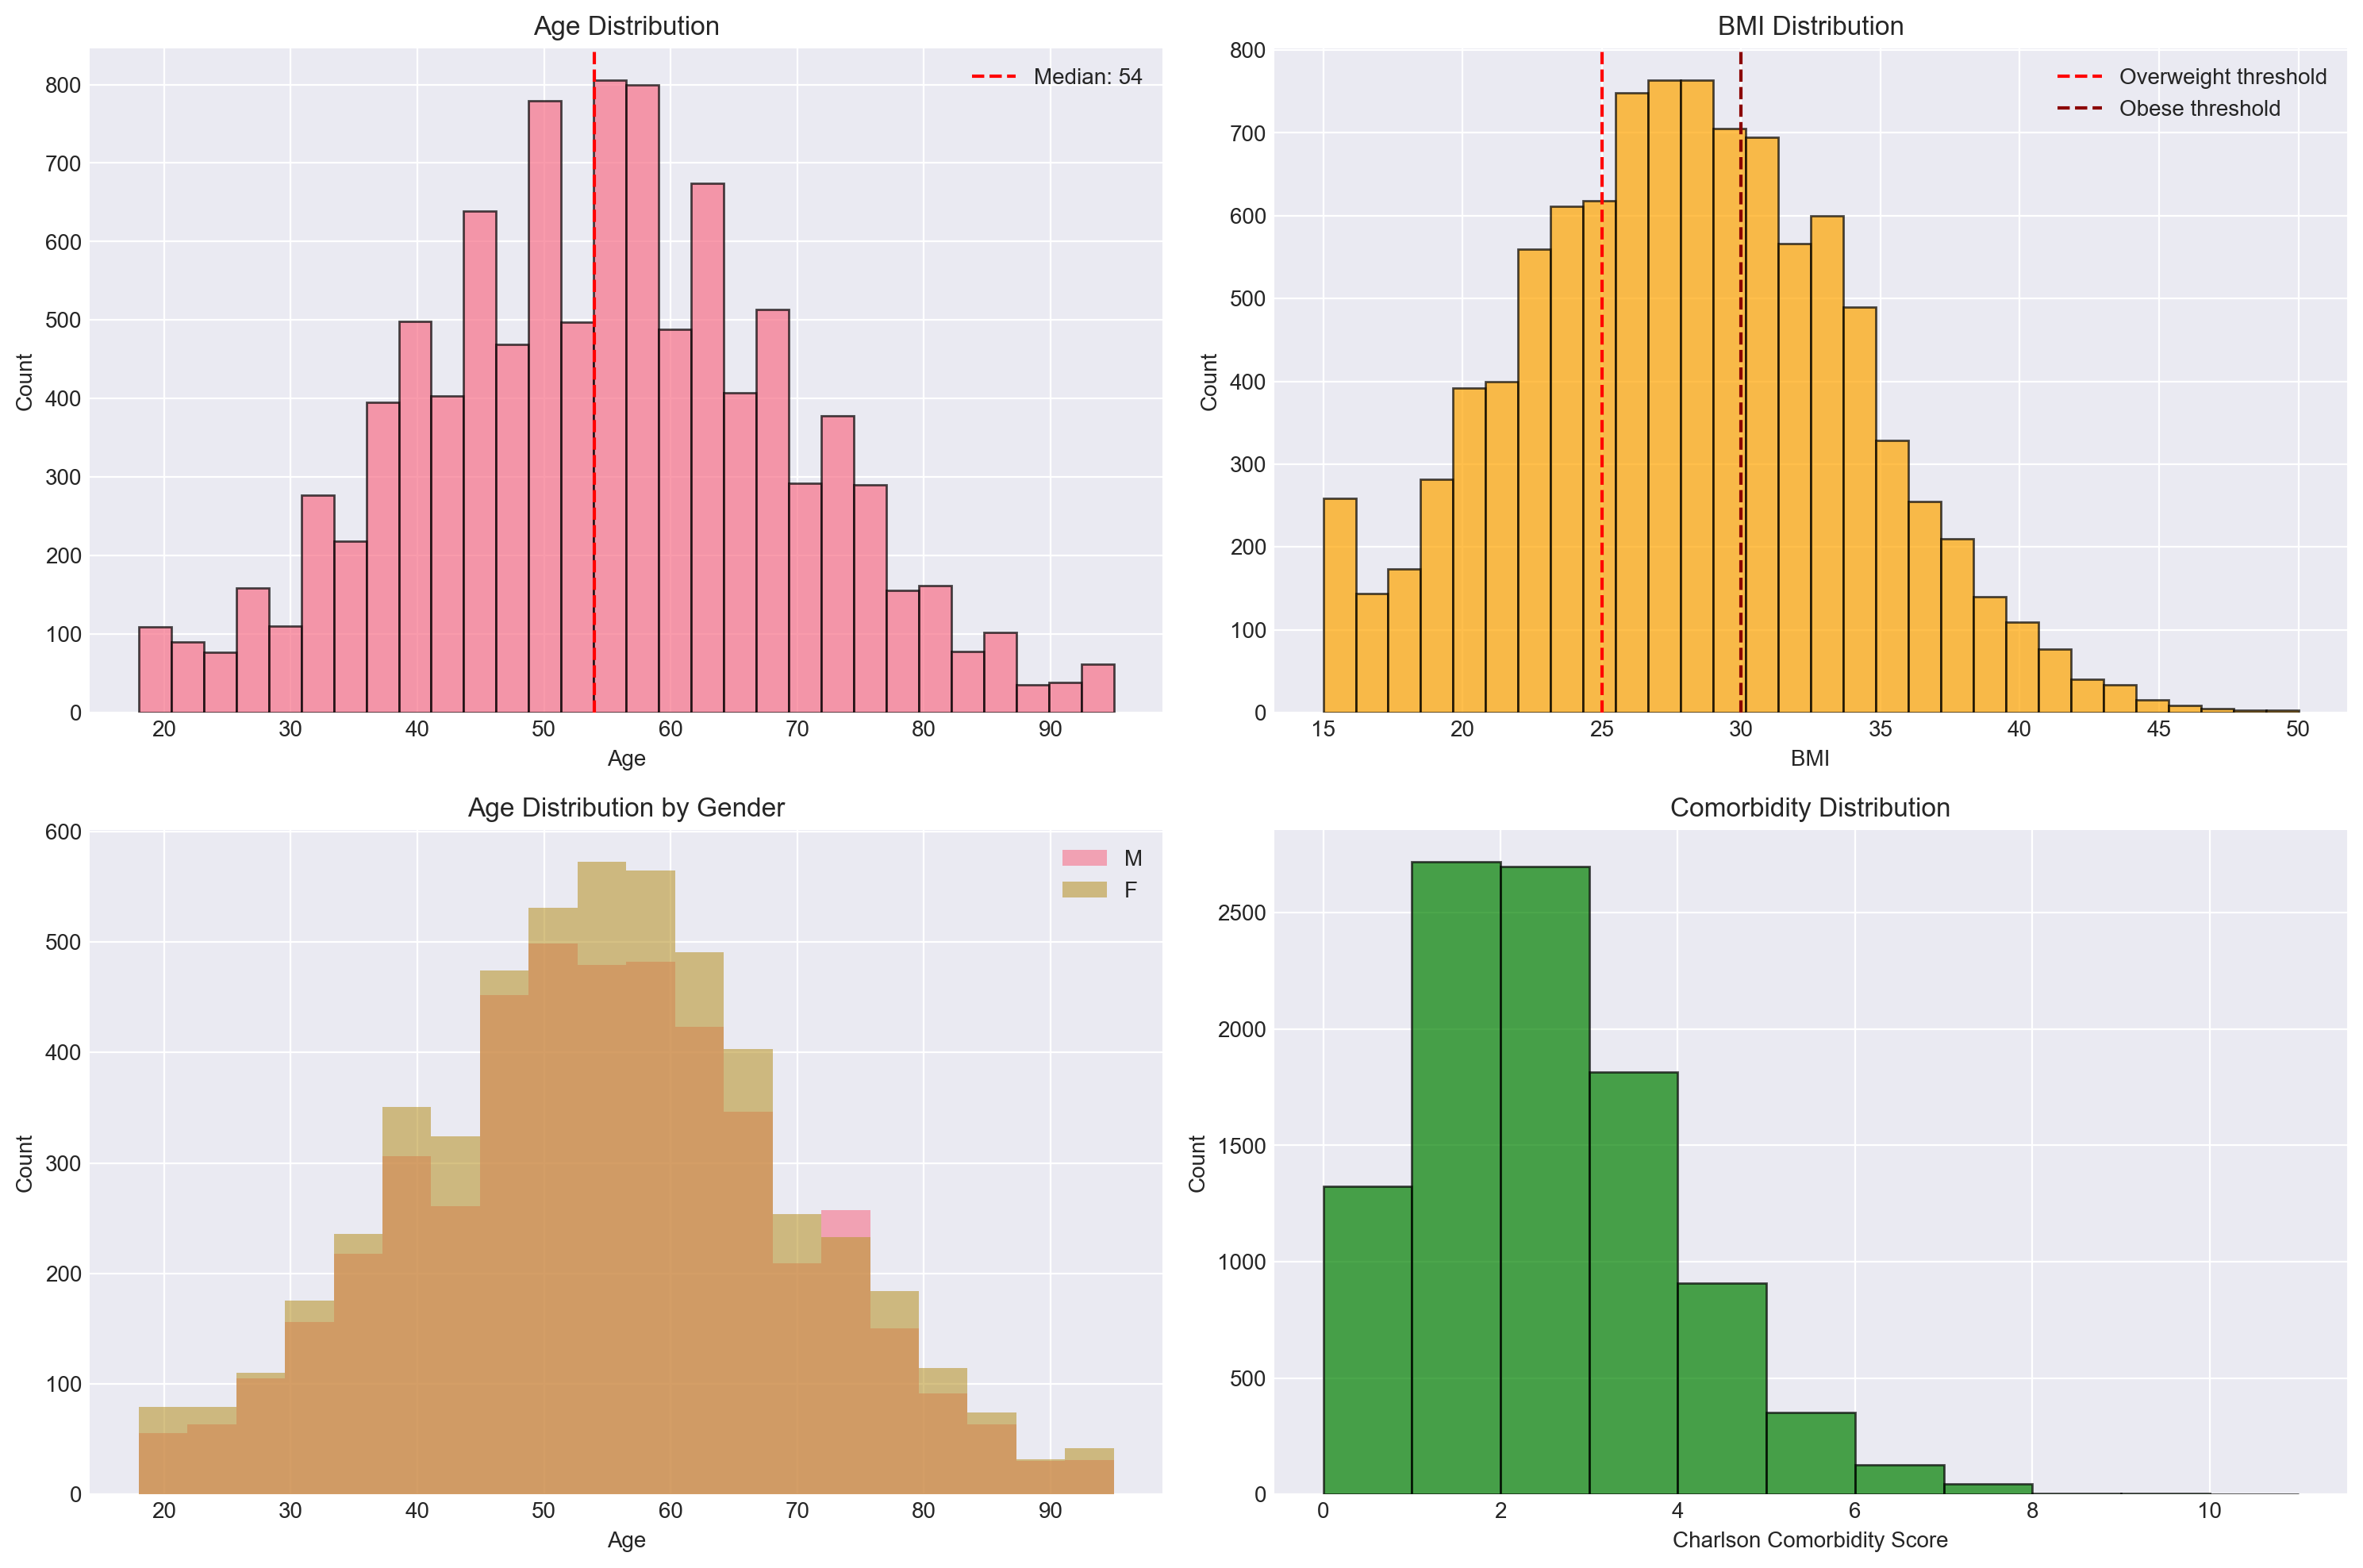

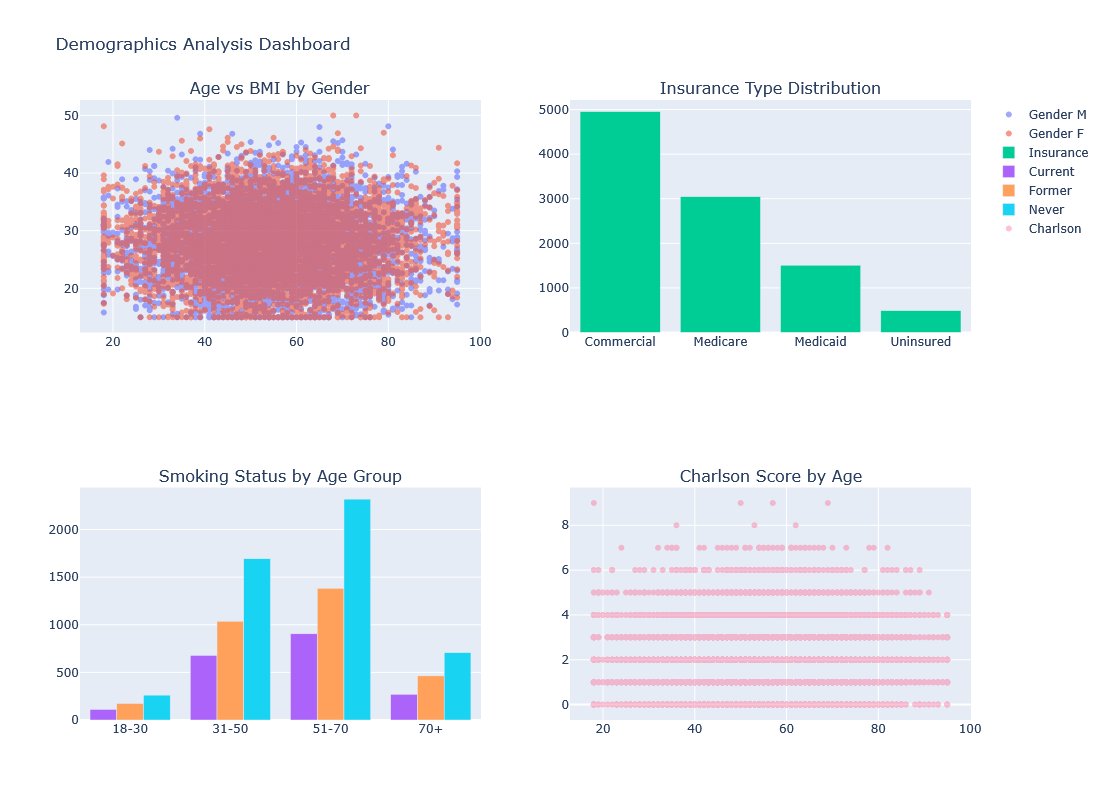


DIAGNOSIS PATTERNS

Top 10 Diagnoses:
diagnosis_desc
Major depressive disorder      3047
Rheumatoid arthritis           3035
Multiple sclerosis             3035
Heart failure                  3031
Type 2 diabetes mellitus       3011
Chronic kidney disease         3003
Breast cancer                  2987
Acute myocardial infarction    2973
COPD                           2961
Lung cancer                    2952
Name: count, dtype: int64

Average diagnoses per patient: 3.33
Max diagnoses for a single patient: 17


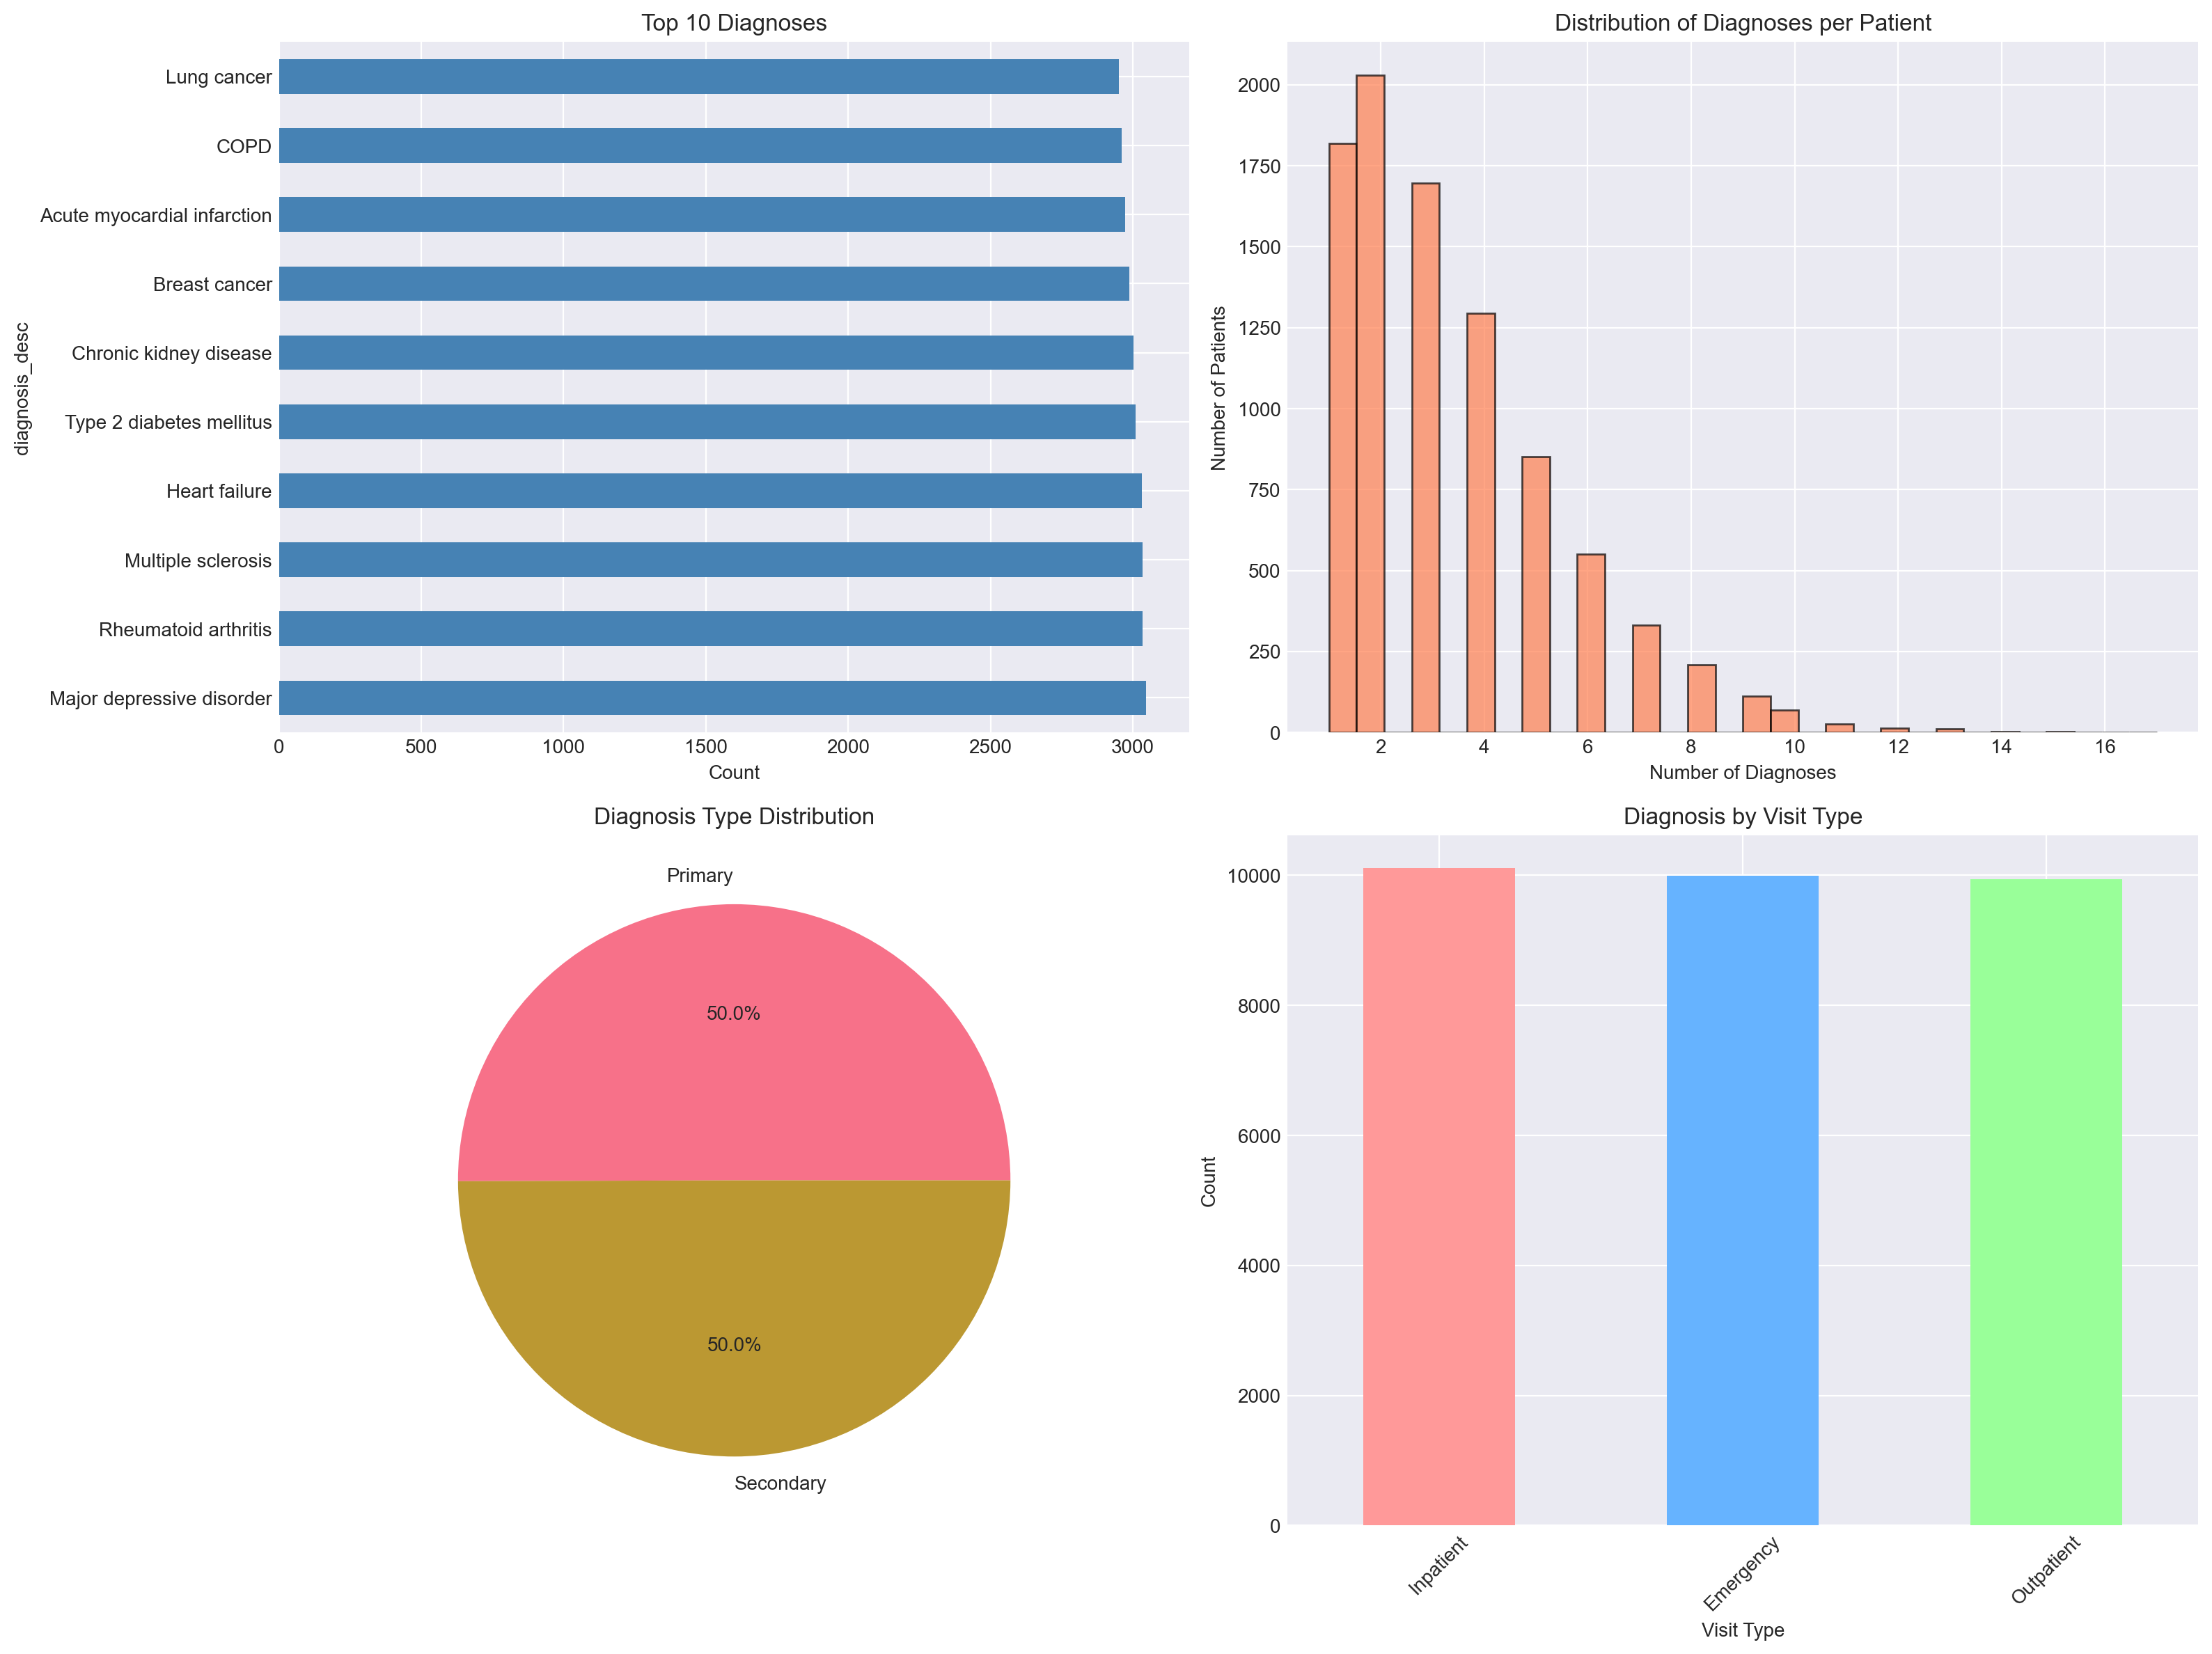


LABORATORY RESULTS

Lab Test Summary:
           test_value                             
                 mean    std    min     max  count
test_name                                         
ALT             30.97  21.06 -64.35  117.57  19916
AST             28.97  19.20 -40.95  126.93  19952
Creatinine       1.03   0.32  -0.11    2.55  19968
HDL             51.56  15.99 -13.05  128.82  19975
HbA1c            5.86   1.32   1.16   12.73  20137
Hemoglobin      13.88   2.27   4.53   25.95  19925
LDL            102.70  32.38 -14.52  264.11  20194
Platelets      257.38  55.24  52.60  519.42  19919
WBC              7.71   2.65  -1.69   21.42  20010
eGFR            92.58  26.83 -14.16  209.38  19705

Percentage of abnormal results: 30.3%


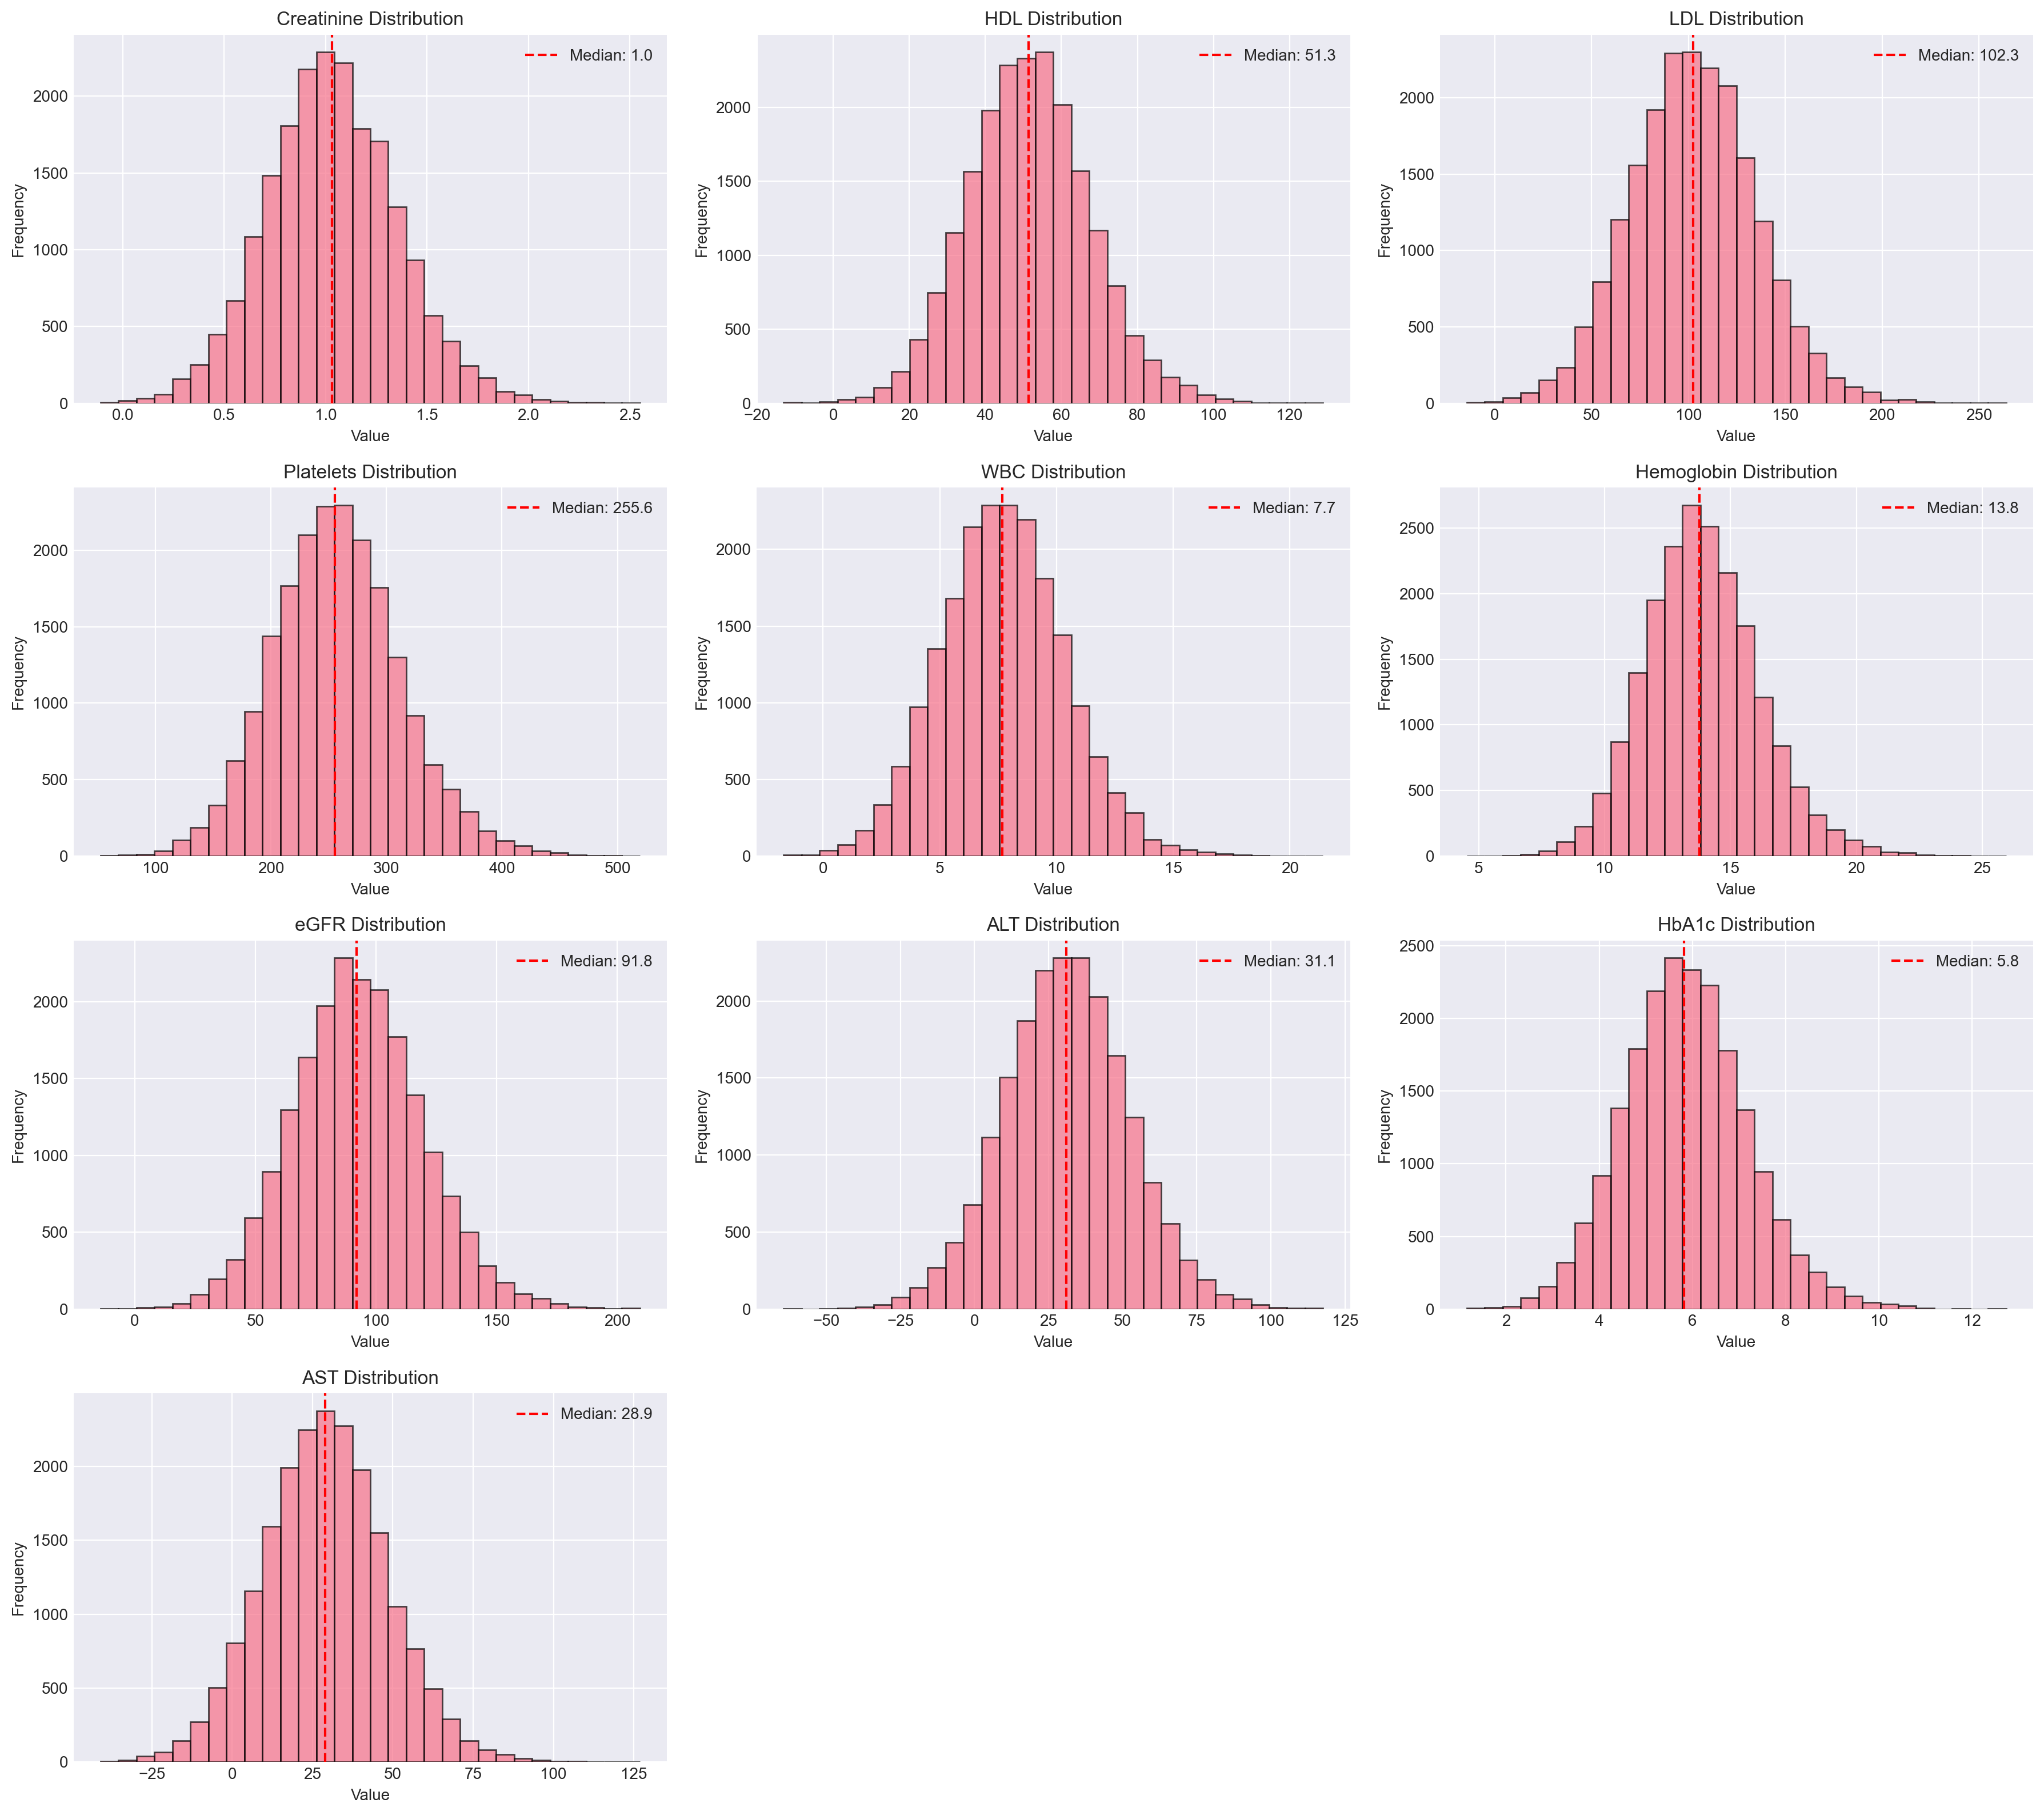


MEDICATION PATTERNS

Top 15 Prescribed Medications:
medication
Carboplatin        1616
Pembrolizumab      1578
Paclitaxel         1536
Nivolumab          1534
Sitagliptin        1093
Fingolimod         1086
Interferon beta    1081
Glipizide          1080
Natalizumab        1056
Insulin            1032
Metformin          1031
Glatiramer         1029
Aspirin             882
Metoprolol          878
Atorvastatin        859
Name: count, dtype: int64

Average treatment duration: 378 days

Prescriptions by Specialty:
prescriber_specialty
Endocrinology        4321
Internal Medicine    4281
Neurology            4266
Cardiology           4114
Oncology             4097
Name: count, dtype: int64


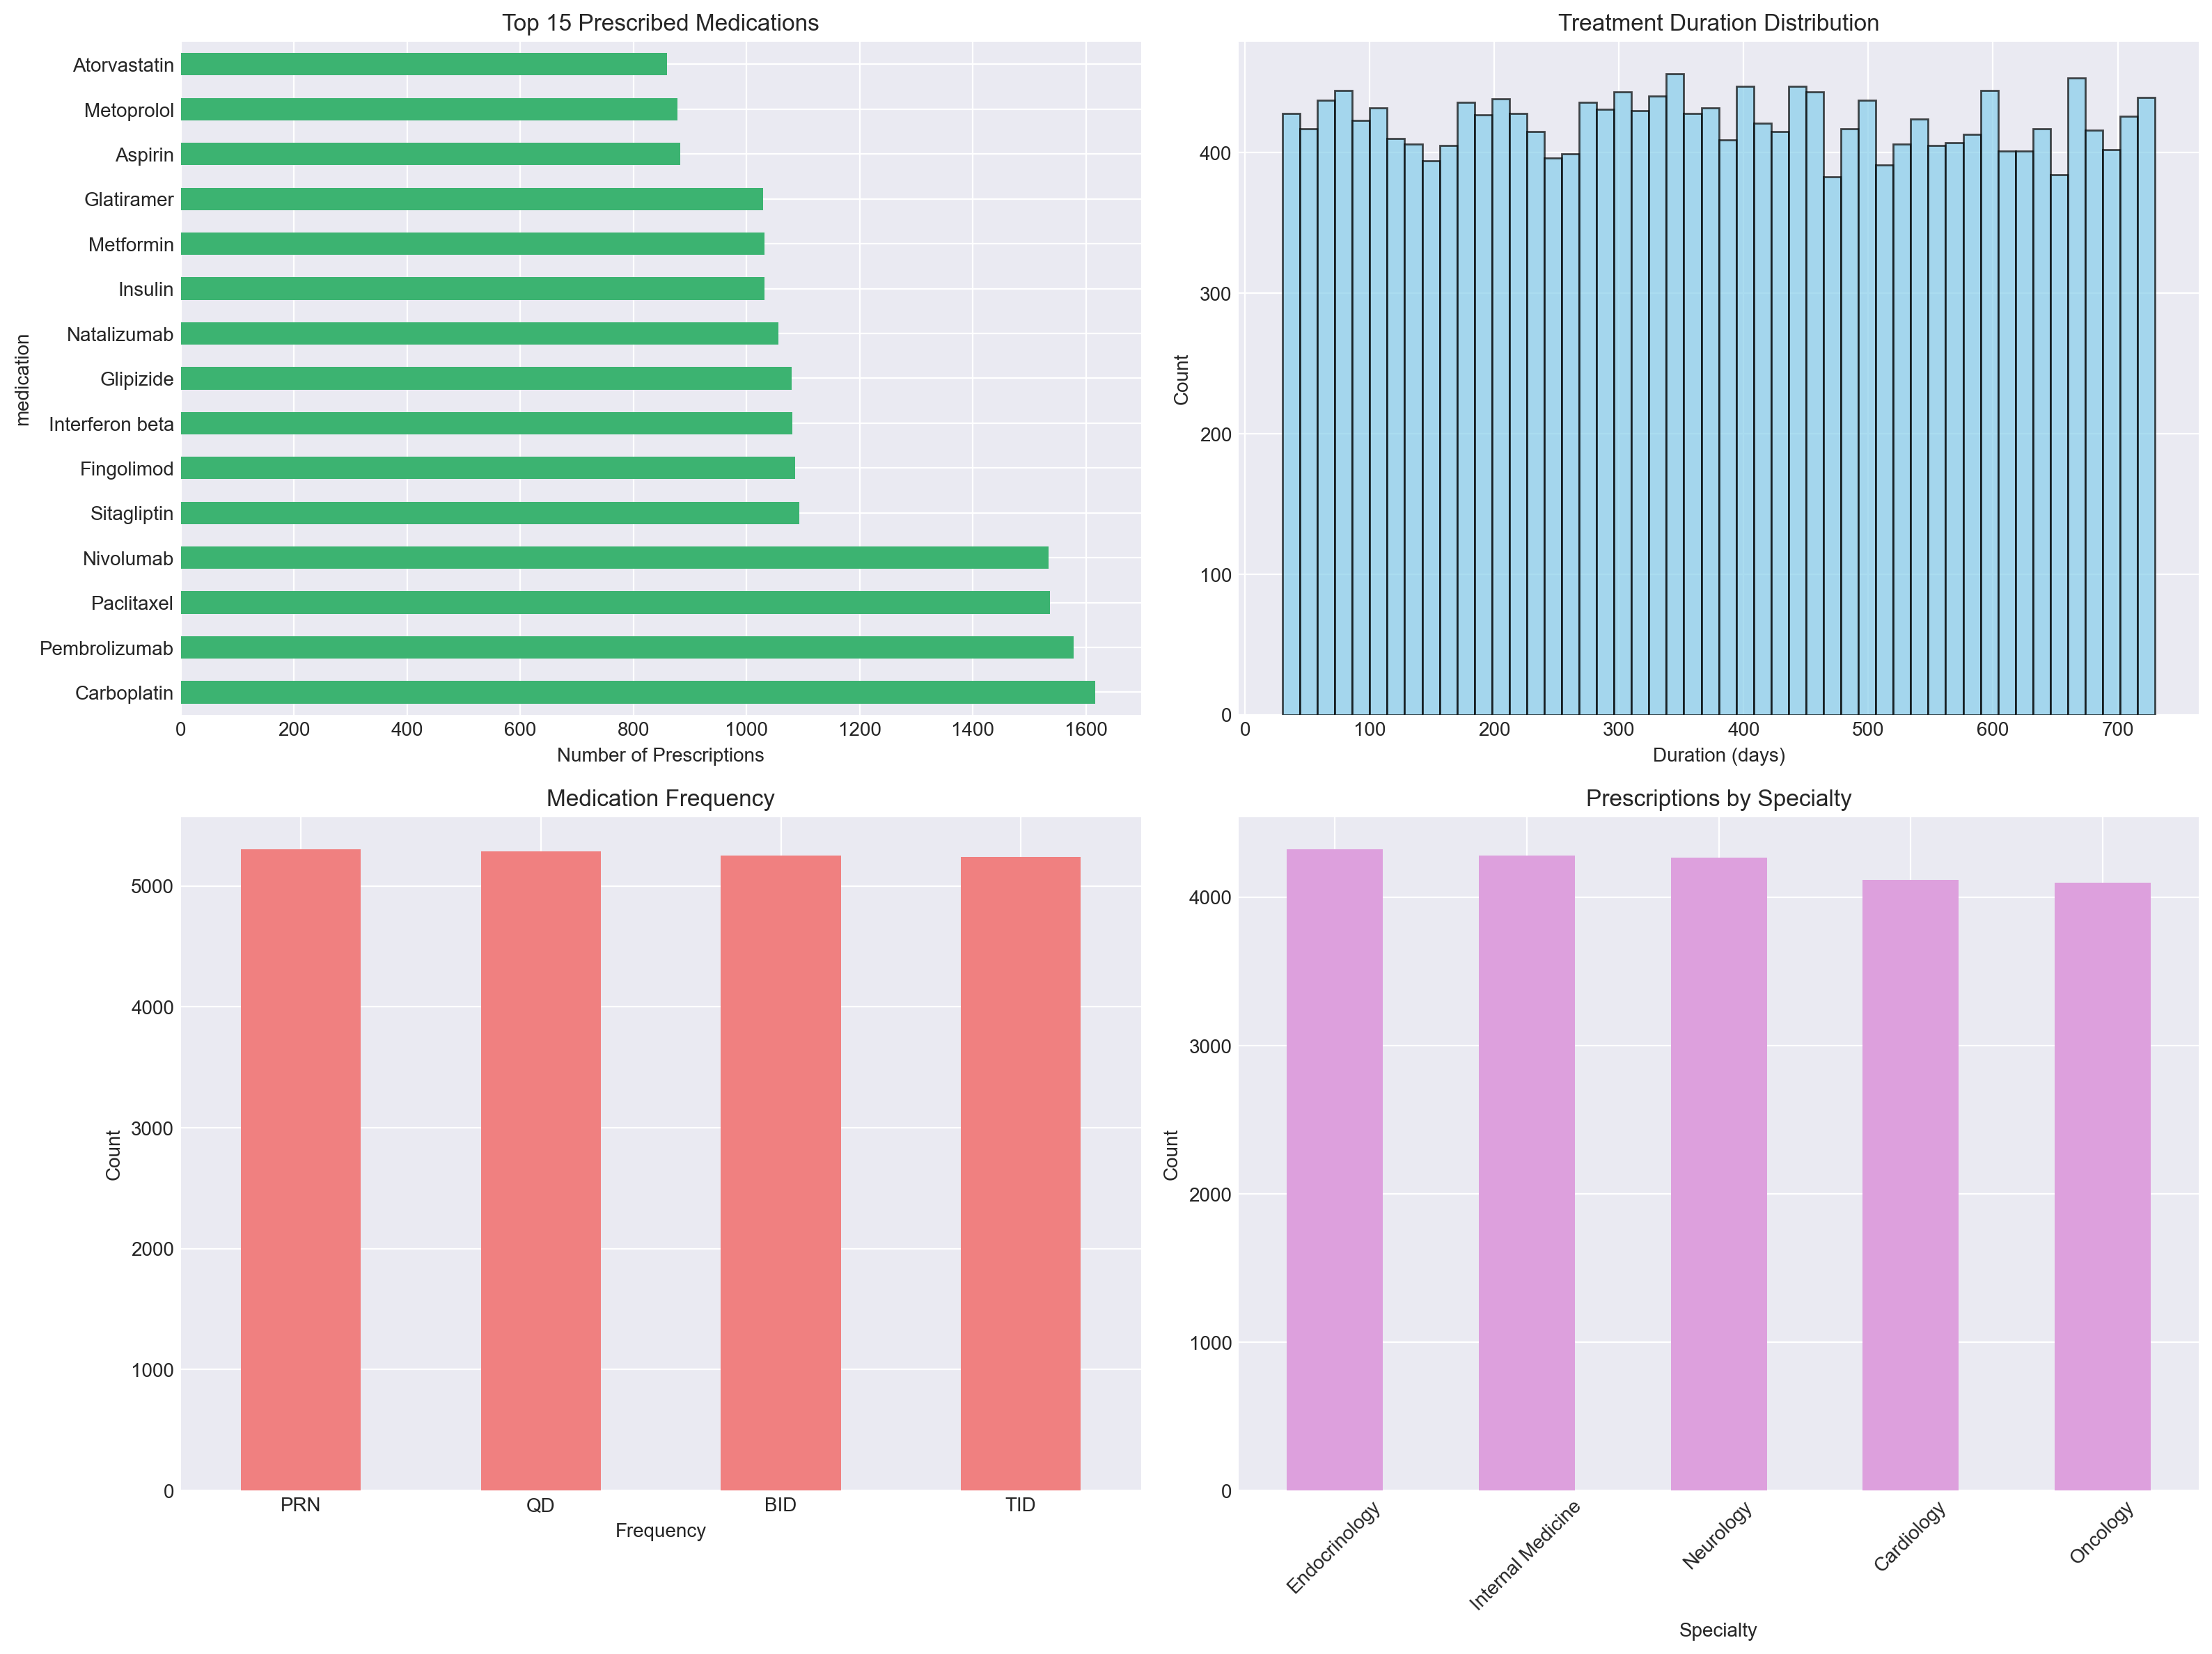


OUTCOMES ANALYSIS

Event Type Distribution:
event_type
Hospitalization        20980
Disease Progression     1618
Death                    846
Name: count, dtype: int64

Total patients: 10,000
Deaths: 846
Mortality rate: 8.46%

Hospitalizations: 20,980
Hospitalization rate: 209.80%


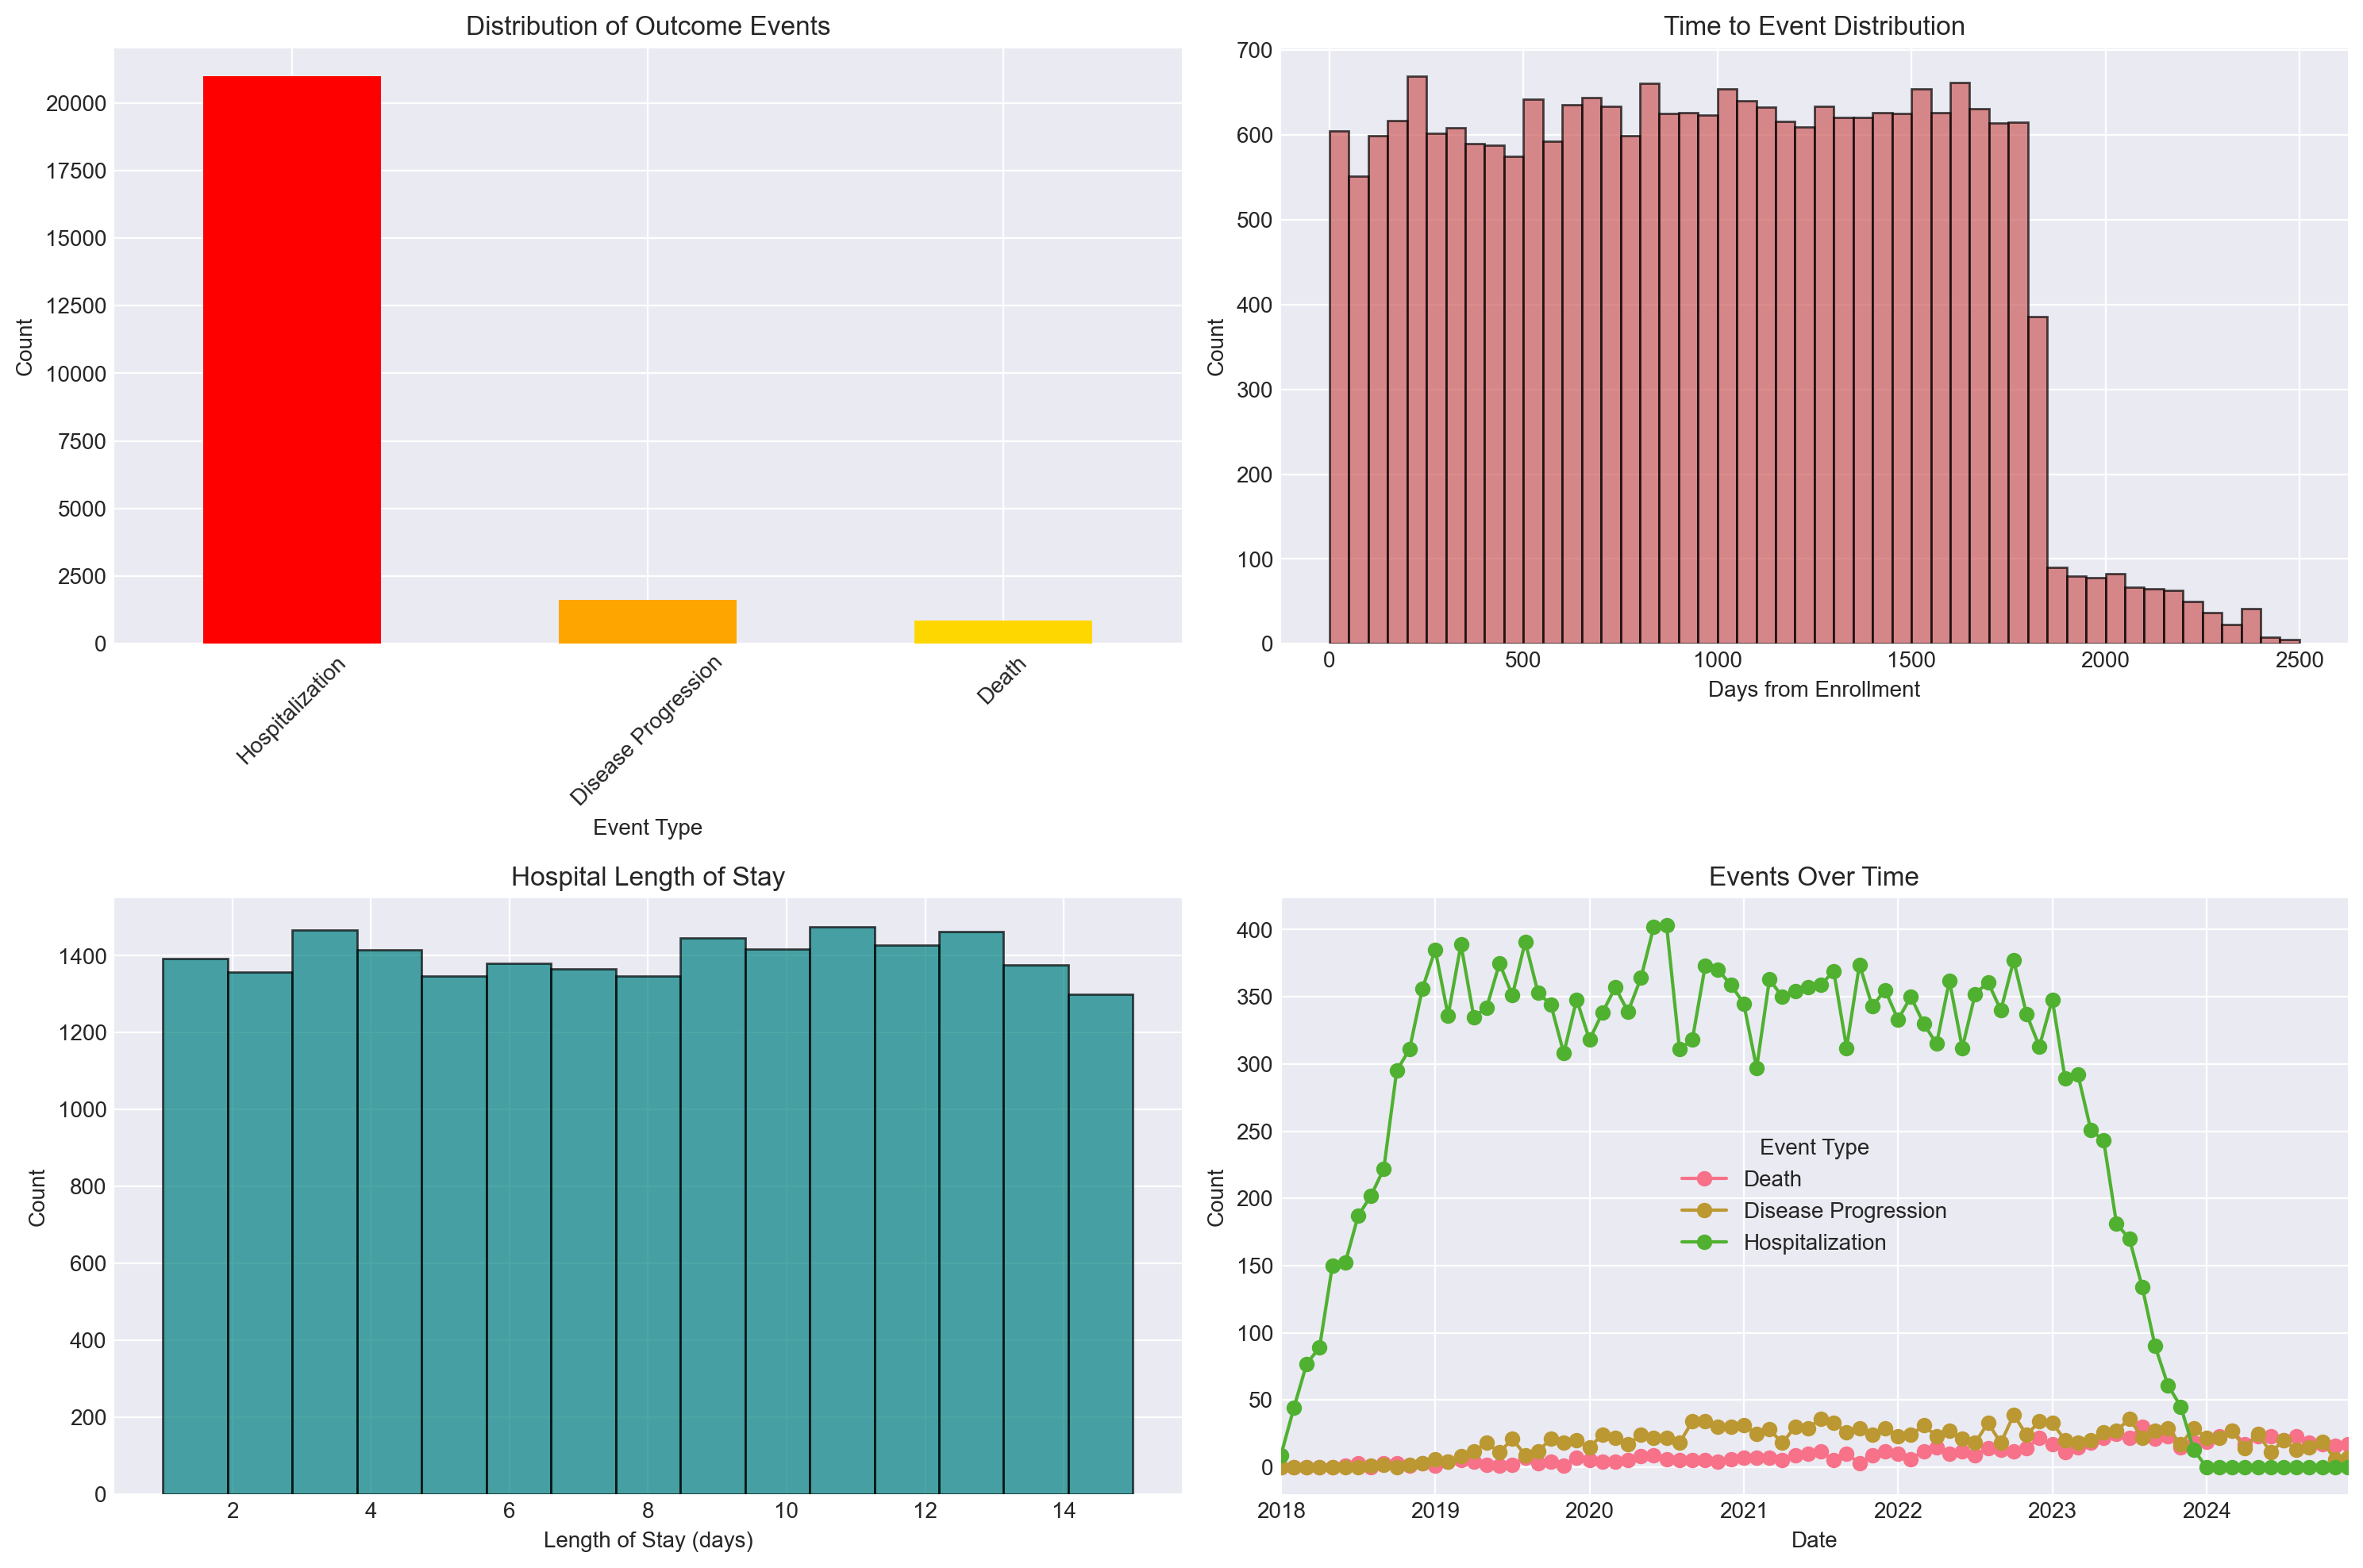


CANCER COHORT ANALYSIS

Cancer cohort size: 4,265 patients
Percentage of total: 42.6%

Cancer Cohort Demographics:
count    4265.000000
mean       54.194842
std        14.821776
min        18.000000
25%        44.000000
50%        54.000000
75%        64.000000
max        95.000000
Name: age, dtype: float64

Gender distribution:
gender
F    2274
M    1991
Name: count, dtype: int64

SUMMARY STATISTICS
total_patients: 10,000
total_diagnoses: 30,035
total_lab_results: 199,701
total_medications: 21,079
total_outcomes: 23,444
avg_age: 54.50
mortality_rate: 8.46
cancer_patients: 4,265

✓ Exploratory Data Analysis Complete!


In [6]:
# %% Load Data
print("Loading healthcare datasets...")
loader = HealthcareDataLoader(data_dir="../data/raw")
datasets = loader.load_all()

demographics = datasets["demographics"]
diagnoses = datasets["diagnoses"]
lab_results = datasets["lab_results"]
medications = datasets["medications"]
outcomes = datasets["outcomes"]

print("✓ Data loaded successfully!")

# %% Demographics Overview

print("=" * 70)
print("DEMOGRAPHICS SUMMARY")
print("=" * 70)
print(f"\nTotal Patients: {len(demographics):,}")

print("\nAge Statistics:")
print(demographics["age"].describe())

print("\nGender Distribution:")
print(demographics["gender"].value_counts())

print("\nRace Distribution:")
print(demographics["race"].value_counts())

print("\nSmoking Status:")
print(demographics["smoking_status"].value_counts())

# Demographics Plots (Matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age histogram
axes[0, 0].hist(demographics["age"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].axvline(
    demographics["age"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {demographics['age'].median():.0f}",
)
axes[0, 0].legend()

# BMI distribution
axes[0, 1].hist(
    demographics["bmi"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="orange",
)
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("BMI Distribution")
axes[0, 1].axvline(25, color="red", linestyle="--", label="Overweight threshold")
axes[0, 1].axvline(30, color="darkred", linestyle="--", label="Obese threshold")
axes[0, 1].legend()

# Gender by age (overlapping histograms)
for gender in demographics["gender"].unique():
    axes[1, 0].hist(
        demographics.loc[demographics["gender"] == gender, "age"],
        bins=20,
        alpha=0.6,
        label=gender,
    )

axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Age Distribution by Gender")
axes[1, 0].legend()

# Charlson score
axes[1, 1].hist(
    demographics["charlson_score"],
    bins=range(0, 12),
    edgecolor="black",
    alpha=0.7,
    color="green",
)
axes[1, 1].set_xlabel("Charlson Comorbidity Score")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Comorbidity Distribution")

plt.tight_layout()
plt.show()

# %% Interactive Demographics (Plotly)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Age vs BMI by Gender",
        "Insurance Type Distribution",
        "Smoking Status by Age Group",
        "Charlson Score by Age",
    ),
    specs=[[{"type": "scatter"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "scatter"}]],
)

# Age vs BMI
for gender in demographics["gender"].unique():
    df_gender = demographics[demographics["gender"] == gender]
    fig.add_trace(
        go.Scatter(
            x=df_gender["age"],
            y=df_gender["bmi"],
            mode="markers",
            name=f"Gender {gender}",
            opacity=0.6,
        ),
        row=1,
        col=1,
    )

# Insurance type
insurance_counts = demographics["insurance_type"].value_counts()
fig.add_trace(
    go.Bar(
        x=insurance_counts.index,
        y=insurance_counts.values,
        name="Insurance",
    ),
    row=1,
    col=2,
)

# Smoking by age group
demographics["age_group"] = pd.cut(
    demographics["age"],
    bins=[0, 30, 50, 70, 100],
    labels=["18-30", "31-50", "51-70", "70+"],
)

smoking_age = demographics.groupby(["age_group", "smoking_status"]).size().unstack()

for status in smoking_age.columns:
    fig.add_trace(
        go.Bar(
            x=smoking_age.index.astype(str),
            y=smoking_age[status],
            name=status,
        ),
        row=2,
        col=1,
    )

# Charlson vs Age
fig.add_trace(
    go.Scatter(
        x=demographics["age"],
        y=demographics["charlson_score"],
        mode="markers",
        opacity=0.4,
        name="Charlson",
    ),
    row=2,
    col=2,
)

fig.update_layout(
    height=800,
    showlegend=True,
    title_text="Demographics Analysis Dashboard",
)
fig.show()

# %% Diagnosis Patterns

print("\n" + "=" * 70)
print("DIAGNOSIS PATTERNS")
print("=" * 70)

# Most common diagnoses
top_diagnoses = diagnoses["diagnosis_desc"].value_counts().head(10)
print("\nTop 10 Diagnoses:")
print(top_diagnoses)

# Diagnoses per patient
dx_per_patient = diagnoses.groupby("patient_id").size()
print(f"\nAverage diagnoses per patient: {dx_per_patient.mean():.2f}")
print(f"Max diagnoses for a single patient: {dx_per_patient.max()}")

# Diagnosis Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top diagnoses
top_diagnoses.plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_title("Top 10 Diagnoses")

# Diagnoses per patient distribution
axes[0, 1].hist(
    dx_per_patient,
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="coral",
)
axes[0, 1].set_xlabel("Number of Diagnoses")
axes[0, 1].set_ylabel("Number of Patients")
axes[0, 1].set_title("Distribution of Diagnoses per Patient")

# Diagnosis type
diagnoses["diagnosis_type"].value_counts().plot(
    kind="pie",
    ax=axes[1, 0],
    autopct="%1.1f%%",
)
axes[1, 0].set_title("Diagnosis Type Distribution")
axes[1, 0].set_ylabel("")

# Visit type
diagnoses["visit_type"].value_counts().plot(
    kind="bar",
    ax=axes[1, 1],
    color=["#ff9999", "#66b3ff", "#99ff99"],
)
axes[1, 1].set_xlabel("Visit Type")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Diagnosis by Visit Type")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# %% Laboratory Results Analysis

print("\n" + "=" * 70)
print("LABORATORY RESULTS")
print("=" * 70)

# Lab test summary
lab_summary = lab_results.groupby("test_name").agg(
    {"test_value": ["mean", "std", "min", "max", "count"]}
).round(2)

print("\nLab Test Summary:")
print(lab_summary)

# Abnormal results
abnormal_pct = (lab_results["abnormal_flag"] == "Y").mean() * 100
print(f"\nPercentage of abnormal results: {abnormal_pct:.1f}%")

# Lab Results Visualization

test_names = lab_results["test_name"].unique()
n_tests = len(test_names)
n_cols = 3
n_rows = (n_tests + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, test in enumerate(test_names):
    test_data = lab_results[lab_results["test_name"] == test]["test_value"]
    axes[idx].hist(test_data, bins=30, edgecolor="black", alpha=0.7)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"{test} Distribution")
    axes[idx].axvline(
        test_data.median(),
        color="red",
        linestyle="--",
        label=f"Median: {test_data.median():.1f}",
    )
    axes[idx].legend()

# Hide empty subplots (if any)
for idx in range(n_tests, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# %% Medication Patterns

print("\n" + "=" * 70)
print("MEDICATION PATTERNS")
print("=" * 70)

# Most prescribed medications
top_meds = medications["medication"].value_counts().head(15)
print("\nTop 15 Prescribed Medications:")
print(top_meds)

# Calculate treatment duration
medications["treatment_duration_days"] = (
    medications["end_date"] - medications["start_date"]
).dt.days

print(
    f"\nAverage treatment duration: {medications['treatment_duration_days'].mean():.0f} days"
)

# Prescriber specialties
print("\nPrescriptions by Specialty:")
print(medications["prescriber_specialty"].value_counts())

# Medication Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top medications
top_meds.plot(kind="barh", ax=axes[0, 0], color="mediumseagreen")
axes[0, 0].set_xlabel("Number of Prescriptions")
axes[0, 0].set_title("Top 15 Prescribed Medications")

# Treatment duration
axes[0, 1].hist(
    medications["treatment_duration_days"],
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color="skyblue",
)
axes[0, 1].set_xlabel("Duration (days)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Treatment Duration Distribution")

# Frequency distribution
medications["frequency"].value_counts().plot(
    kind="bar",
    ax=axes[1, 0],
    color="lightcoral",
)
axes[1, 0].set_xlabel("Frequency")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Medication Frequency")
axes[1, 0].tick_params(axis="x", rotation=0)

# Prescriber specialty
medications["prescriber_specialty"].value_counts().plot(
    kind="bar",
    ax=axes[1, 1],
    color="plum",
)
axes[1, 1].set_xlabel("Specialty")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Prescriptions by Specialty")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# %% Outcomes Analysis

print("\n" + "=" * 70)
print("OUTCOMES ANALYSIS")
print("=" * 70)

print("\nEvent Type Distribution:")
print(outcomes["event_type"].value_counts())

# Death rate
total_patients = demographics["patient_id"].nunique()
deaths = len(outcomes[outcomes["event_type"] == "Death"])
death_rate = (deaths / total_patients) * 100

print(f"\nTotal patients: {total_patients:,}")
print(f"Deaths: {deaths:,}")
print(f"Mortality rate: {death_rate:.2f}%")

# Hospitalization rate
hospitalizations = len(outcomes[outcomes["event_type"] == "Hospitalization"])
hosp_rate = (hospitalizations / total_patients) * 100
print(f"\nHospitalizations: {hospitalizations:,}")
print(f"Hospitalization rate: {hosp_rate:.2f}%")

# Outcomes Visualization

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Event types
outcomes["event_type"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0],
    color=["red", "orange", "gold"],
)
axes[0, 0].set_xlabel("Event Type")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Outcome Events")
axes[0, 0].tick_params(axis="x", rotation=45)

# Time to events
enrollment_map = demographics.set_index("patient_id")["enrollment_date"]
outcomes["days_from_enrollment"] = (
    outcomes["event_date"] - outcomes["patient_id"].map(enrollment_map)
).dt.days

axes[0, 1].hist(
    outcomes["days_from_enrollment"],
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color="indianred",
)
axes[0, 1].set_xlabel("Days from Enrollment")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Time to Event Distribution")

# Length of stay for hospitalizations
hosp_data = outcomes[outcomes["event_type"] == "Hospitalization"]
if "los_days" in hosp_data.columns and len(hosp_data) > 0:
    axes[1, 0].hist(
        hosp_data["los_days"].dropna(),
        bins=15,
        edgecolor="black",
        alpha=0.7,
        color="teal",
    )
    axes[1, 0].set_xlabel("Length of Stay (days)")
    axes[1, 0].set_ylabel("Count")
    axes[1, 0].set_title("Hospital Length of Stay")

# Events over time
outcomes_monthly = (
    outcomes.set_index("event_date")
    .groupby([pd.Grouper(freq="M"), "event_type"])
    .size()
    .unstack(fill_value=0)
)

outcomes_monthly.plot(ax=axes[1, 1], marker="o")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Events Over Time")
axes[1, 1].legend(title="Event Type")

plt.tight_layout()
plt.show()

# %% Cohort Analysis Example

print("\n" + "=" * 70)
print("CANCER COHORT ANALYSIS")
print("=" * 70)

# Identify cancer patients
cancer_patients = diagnoses[
    diagnoses["diagnosis_desc"].str.contains("cancer", case=False)
]["patient_id"].unique()

cancer_cohort = demographics[demographics["patient_id"].isin(cancer_patients)]

print(f"\nCancer cohort size: {len(cancer_cohort):,} patients")
print(f"Percentage of total: {len(cancer_cohort)/len(demographics)*100:.1f}%")

print("\nCancer Cohort Demographics:")
print(cancer_cohort["age"].describe())
print("\nGender distribution:")
print(cancer_cohort["gender"].value_counts())

# Save processed data summary

summary_stats = {
    "total_patients": len(demographics),
    "total_diagnoses": len(diagnoses),
    "total_lab_results": len(lab_results),
    "total_medications": len(medications),
    "total_outcomes": len(outcomes),
    "avg_age": demographics["age"].mean(),
    "mortality_rate": death_rate,
    "cancer_patients": len(cancer_cohort),
}

print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value:,}")

print("\n✓ Exploratory Data Analysis Complete!")



CROSS-DOMAIN CLINICAL VIEW — CANCER COHORT

Events per patient (head):


event_type,Death,Disease Progression,Hospitalization
patient_id,,,
P000003,0,0,4
P000004,1,0,2
P000011,0,0,1
P000012,0,1,2
P000014,0,1,2



Patients with ≥1 hospitalization (cancer cohort): 3662
Patients with ≥1 death event (cancer cohort):    348
Patients with ≥1 progression event:              1618


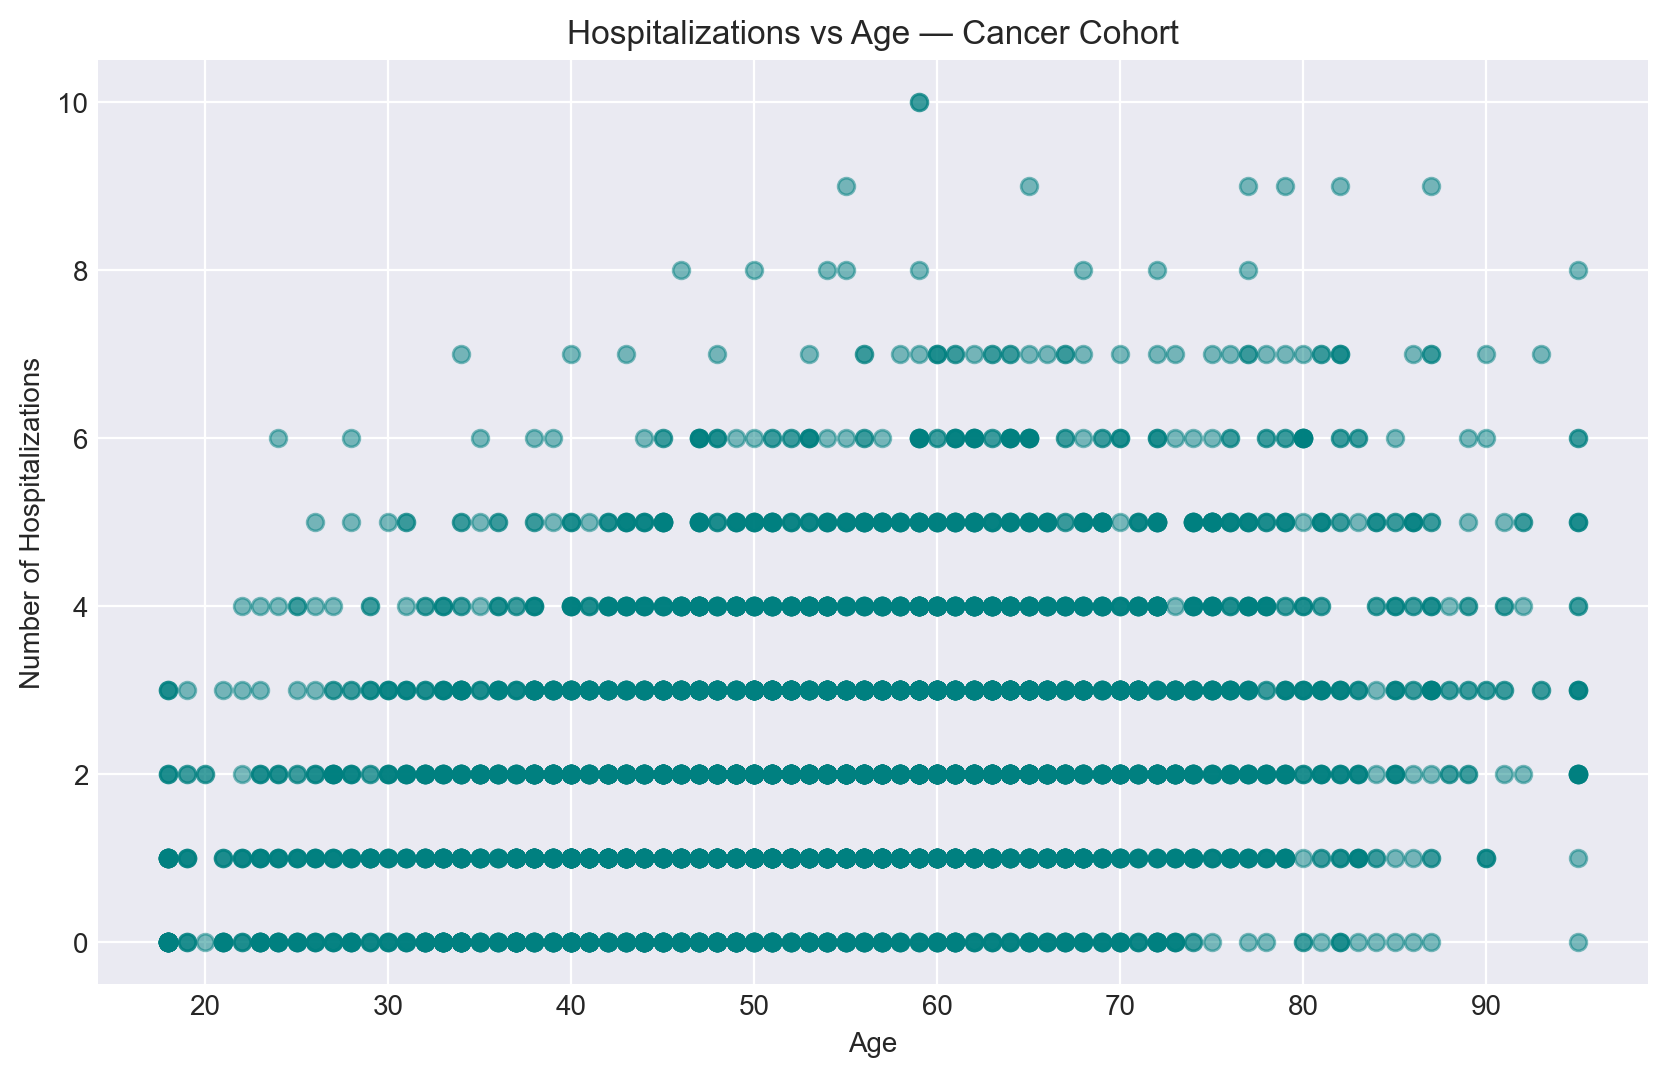

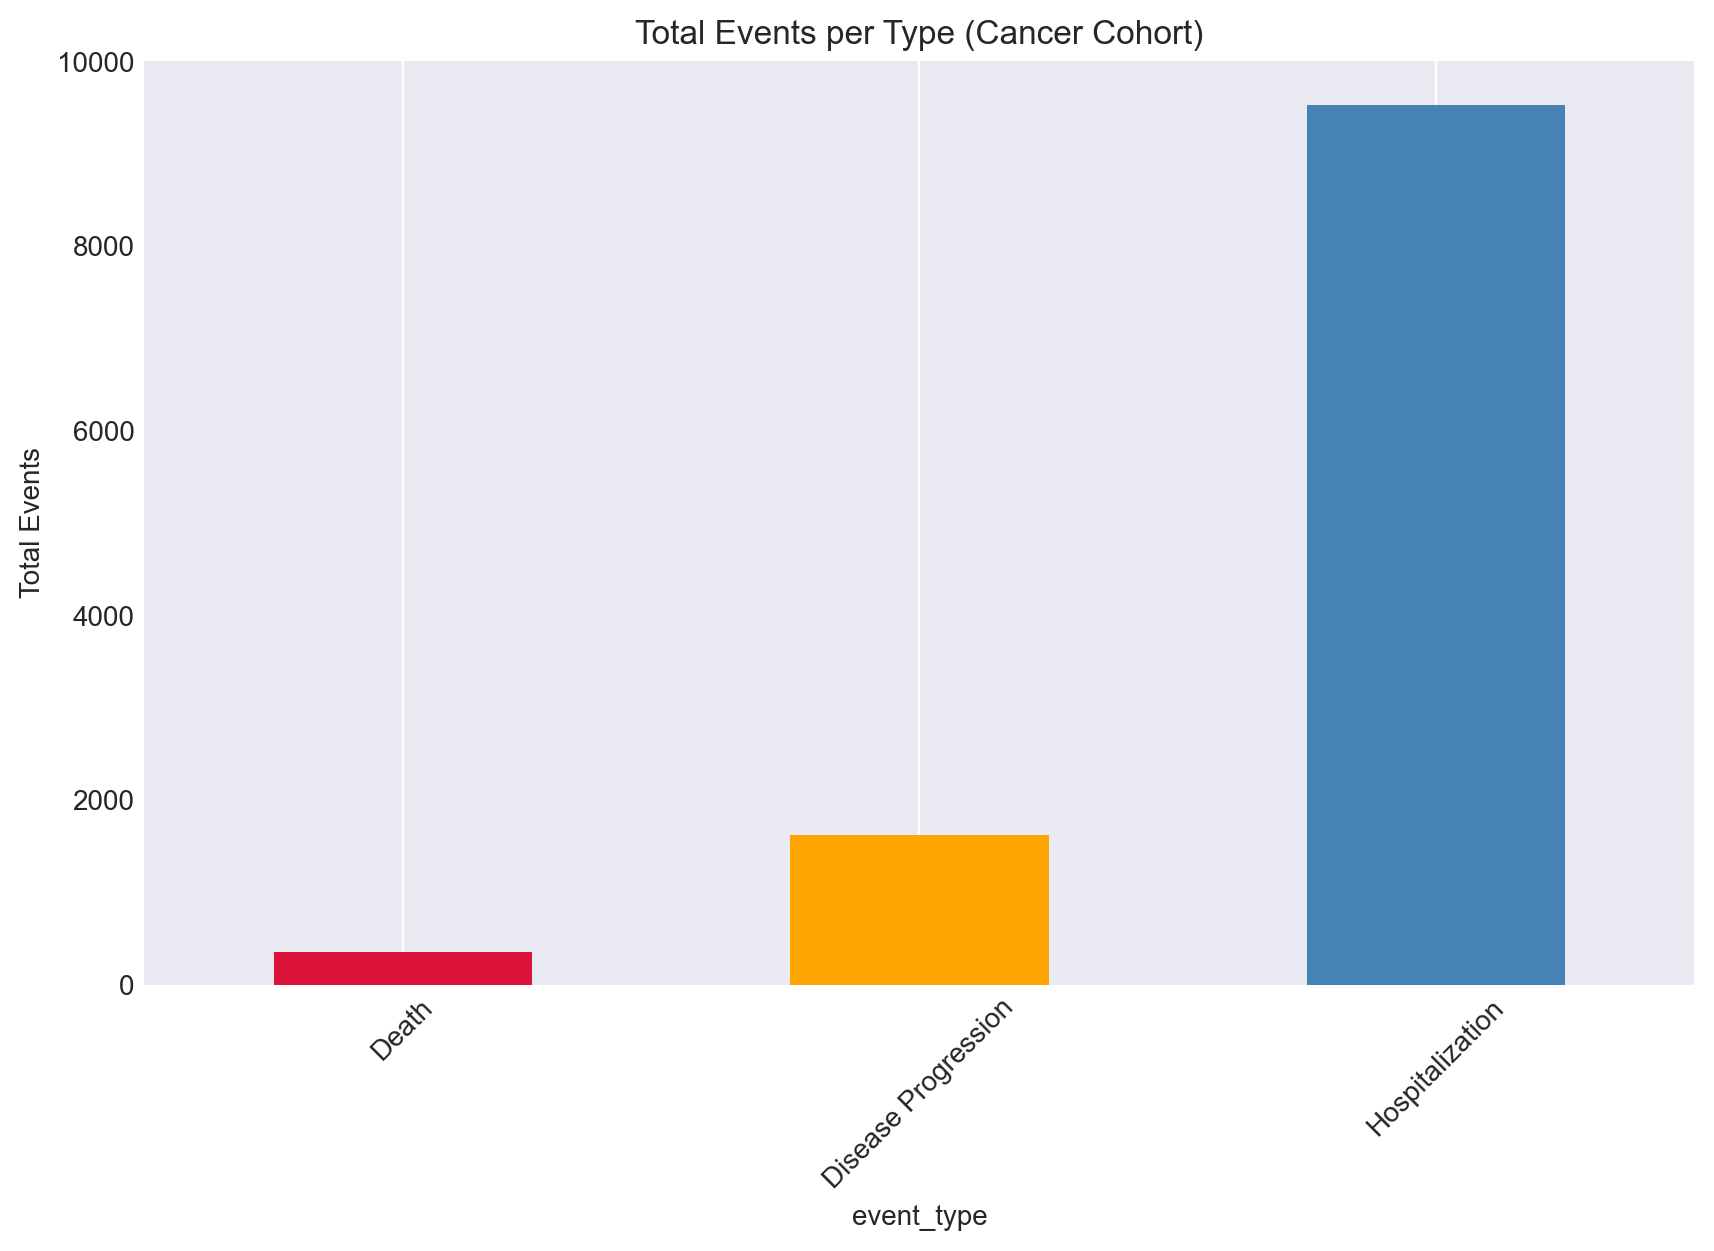

In [9]:
# %% Cross-domain clinical view (cancer cohort)

print("\n" + "=" * 70)
print("CROSS-DOMAIN CLINICAL VIEW — CANCER COHORT")
print("=" * 70)

# 1. Build event counts per patient
events_per_patient = (
    outcomes[outcomes["patient_id"].isin(cancer_patients)]
    .groupby(["patient_id", "event_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nEvents per patient (head):")
display(events_per_patient.head())

# 2. Compute aggregated clinical burdens
n_cancer_hosp = (events_per_patient.get("Hospitalization", 0) > 0).sum()
n_cancer_deaths = (events_per_patient.get("Death", 0) > 0).sum()
n_cancer_progression = (events_per_patient.get("Disease Progression", 0) > 0).sum()

print(f"\nPatients with ≥1 hospitalization (cancer cohort): {n_cancer_hosp}")
print(f"Patients with ≥1 death event (cancer cohort):    {n_cancer_deaths}")
print(f"Patients with ≥1 progression event:              {n_cancer_progression}")

# 3. Merge cancer demographics + events
merged_cancer = cancer_cohort.merge(
    events_per_patient.reset_index(), on="patient_id", how="left"
)

event_cols = events_per_patient.columns
merged_cancer[event_cols] = merged_cancer[event_cols].fillna(0)

# 4. Visualization: hospitalizations vs age
plt.figure(figsize=(10, 6))
plt.scatter(
    merged_cancer["age"],
    merged_cancer["Hospitalization"],
    alpha=0.5,
    color="teal",
)
plt.xlabel("Age")
plt.ylabel("Number of Hospitalizations")
plt.title("Hospitalizations vs Age — Cancer Cohort")
plt.grid(True)
plt.show()

# 5. Visualization: events distribution
plt.figure(figsize=(10, 6))
events_per_patient.sum().plot(kind="bar", color=["crimson", "orange", "steelblue"])
plt.ylabel("Total Events")
plt.title("Total Events per Type (Cancer Cohort)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


## Key Insights from the Exploratory Analysis (Recruiter-Friendly Summary)

Our exploratory analysis of 10,000 synthetic EHR patient records provides strong evidence that the dataset—and the analytical workflow behind it—are robust, clinically meaningful, and ready for downstream modelling.

## Population Overview

10,000 patients with realistic demographic variability.

Median age around 55 years, balanced gender distribution.

Clear presence of chronic-disease risk factors (BMI, smoking, comorbidities).

Comorbidity burden aligns with patterns observed in real-world RWE datasets.

## Clinical Diagnoses

The most common diagnoses correspond to high-prevalence chronic conditions.

Patients present meaningful multi-morbidity, averaging ≈3 diagnoses per patient, enabling realistic clustering and risk-modelling tasks.

## Laboratory Results

~200k lab measurements across multiple test categories.

Distributions show credible physiological variation (normal/log-normal).

Abnormal results occur at a realistic rate, supporting clinical risk stratification.

## Medication Utilization

Over 21,000 prescriptions with heterogeneous treatment windows.

Multiple prescriber specialties highlight multidisciplinary patient journeys.

Data supports modelling of adherence, treatment patterns and pharmaco-epidemiology.

## Clinical Outcomes

More than 23,000 time-stamped outcome events.

Hospitalizations are the most frequent event; overall mortality: 8.46%.

Temporal dynamics of events allow survival analysis and longitudinal modelling.

## Cancer Cohort Insights

A cancer subcohort was extracted using diagnosis patterns:

4,265 patients (42.6% of population)

3,662 had ≥1 hospitalization

348 experienced ≥1 death event

Strong clinical heterogeneity suitable for:

survival modelling

progression analysis

patient segmentation

causal inference workflows
